This notebook contains the code needed to investigate pulsar flux variability using the VAST data. 

It is split into two main sections.

In the first section, all the required data is obtained. Pulsar source objects are created by querying the VAST data using coordinates from the ATNF pulsar catalogue, and nonvariable source objects near each pulsar are found in the VAST data to be used as controls when determining the significance of each pulsar's variability. Additionally, a chi-squared test statistic value is calculated for each pulsar and control source, and a p-value is calculated for each pulsar. 

The second section contains plots, such as histograms for the chi-squared values, lightcurves for the pulsar-control pairs, and other miscellaneous plots which could give insight into correlations between the properties of a pulsar and its resultant variability.

In [1]:
# Installing psrqpy to access known pulsar table
!pip install psrqpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 617.0 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 341.0 kB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.2/242.2 kB 1.4 MB/s eta 0:00:00a 0:00:01
  Created wheel for ads: filename=ads-0.12.3-py3-none-any.whl size=37377 sha256=3baa3a7eb79e5f811b8f843bfeb91859516d410b575451a0f233542acff51d00
  Stored in directory: /home/ben-lorenz12/.cache/pip/wheels/7a/ce/82/bdef3e2f7ec5de4d98a8748202c11cb8af7288cdf3b7be4882
  Created wheel for httpretty: filename=httpretty-0.8.10-py3-none-any.whl size=23997 sha256=2dc15d3857d2d1487c720040f607c197f6ef020b4f893d109851b1ccfeeb3cc4
  Stored in directory: /home/ben-lorenz12/.cache/pip/wheels/6c/68/92/b970c457ae58e02209c65b5f66657c115fa740affe70c03114
Successfully built ads httpretty


In [7]:
# importing required modules
import psrqpy
import matplotlib.pyplot as plt
from vasttools.query import Query
import pandas as pd

from vasttools.moc import VASTMOCS
from astropy import units as u

import numpy as np

from astropy.coordinates import SkyCoord

from scipy.stats import chi2

In [3]:
# setting plot preferences
%matplotlib inline

In [8]:
#computes how many times a source has been detected in VAST
def num_detections(source_df):
    bools = pd.isna(source_df['flux_peak'])
    counter = 0
    for item in bools:
        if not item:
            counter += 1
    return counter

In [9]:
# calculates a weighted mean of flux density for sources
def weighted_mean_flux_density(source_df):
    sum_1overvariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            oneOverVariance = 1 / source_df['rms_image'].iloc[i]
            sum_1overvariance += (oneOverVariance ** 2)
    sumSovervariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] **2
            sumSovervariance += (S/var)
    return sumSovervariance / sum_1overvariance       

In [10]:
# calculates chi_squared of a single source
def chi_squared(source_df):
    n_epochs = 0
    S_weighted = weighted_mean_flux_density(source_df)
    temp = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] ** 2
            num = (S - S_weighted)**2
            temp += num / var
            n_epochs += 1
    return (temp, n_epochs)

In [11]:
# calculates modulation index of a single source
def calc_modulation(source_df):
    return 100 * (source_df['flux_peak'].std() / source_df['flux_peak'].mean())

In [12]:
# calculates average distance between detection in VAST and known sourve coordinates
def calc_avg_separation(source_df):
    sep_list = []
    for i in np.arange(source_df.shape[0]):
        if not (np.isnan(source_df['ra_deg_cont'][i]) or np.isnan(source_df['dec_deg_cont'][i])):
            detected_skycoord = SkyCoord(str(source_df['ra_deg_cont'][i]) + " " + str(source_df['dec_deg_cont'][i]), unit='deg')
            database_skycoord = source_df['skycoord'][i]
            sep_list.append(detected_skycoord.separation(database_skycoord).arcsec)
    return np.mean(sep_list)

In [13]:
# Grab all the pulsars from ATNF catalog
pulsars = psrqpy.QueryATNF(params=["JNAME", "RAJD", "DECJD", "GB", "P0", "P1", "DM", "S1400", "ASSOC", "Age"]) 

In [14]:
moc30 = VASTMOCS.load_pilot_epoch_moc("30") # Select observing epoch 30

In [15]:
# Give the RA and Dec values and get a mask (True if the pulsar is inside the field of view, false else)
in_pilot = moc30.contains(pulsars.table['RAJD'].data*u.deg, pulsars.table['DECJD'].data*u.deg, keep_inside=True) 

In [16]:
filtered_psrs = pulsars.table[in_pilot] # Filter out pulsars not in VAST footprint

In [17]:
#throwing out psrs in globular clusters or with high error in RA and DEC (certainty less than about an arcsec) or zero error (weird)
final_atnf_table = filtered_psrs[(filtered_psrs['ASSOC']!="GC")&(filtered_psrs['DECJD_ERR']<0.001)&(filtered_psrs['RAJD_ERR']<0.001)&(filtered_psrs['DECJD_ERR']!=0)&(filtered_psrs['RAJD_ERR']!=0)]

In [18]:
#creating a dataframe of pulsars and filling it with placeholder columns for various fields
pre_final_df = final_atnf_table.to_pandas()

pre_final_df.insert(0, 'chi_squared', 0)
pre_final_df.insert(0, 'modulation', 0)

pre_final_df.insert(0, 'separation', 0)

pre_final_df.insert(0, 'reduced_chi_squared', 0)

pre_final_df.insert(0, 'mod_results_index', 0)

pre_final_df.insert(0, 'p_value', np.nan)

pre_final_df.insert(0, 'DOF', 0)

In [19]:
#removing the pulsars not in the galactic plane. This produces our "final" dataframe of pulsars
final_df = pre_final_df[(pre_final_df['GB']<5)&(pre_final_df['GB']>-5)]
final_df.reset_index(inplace=True)

In [20]:
# a printout of the final dataframe. Notice that there are a few columns (p value and chi squared, for example) which are not filled in with
# values. We will fill these in using the methods defined above later.
final_df

,index,DOF,p_value,mod_results_index,reduced_chi_squared,separation,modulation,chi_squared,DECJD,S1400_ERR,...,P0_ERR,RAJD_ERR,AGE,P0,JNAME,GB,S1400,DM,P1,P1_ERR
0,47,0,NaN,0,0,0,0,0,-34.395306,1.100,...,6.524284e-13,1.250000e-05,3.762545e+06,0.255427,J1705-3423,3.975259,5.300,146.40000,1.075600e-15,3.914570e-20
1,48,0,NaN,0,0,0,0,0,-34.445556,0.400,...,2.395121e-11,4.166667e-05,2.606509e+06,0.692116,J1708-3426,3.406894,2.000,188.70000,4.207125e-15,9.580483e-20
2,49,0,NaN,0,0,0,0,0,-35.106289,0.020,...,6.088937e-16,4.166667e-07,6.249985e+09,0.004505,J1708-3506,3.123745,1.450,146.76360,1.142082e-20,1.014823e-23
3,51,0,NaN,0,0,0,0,0,-32.791667,NaN,...,8.000000e-11,4.166667e-04,2.170314e+08,1.260214,J1715-3247,3.295828,0.080,164.00000,9.200000e-17,7.000000e-18
4,52,0,NaN,0,0,0,0,0,-34.416547,0.800,...,6.030202e-11,2.554830e-05,1.060680e+06,0.656299,J1717-3425,2.024723,3.900,583.46000,9.803557e-15,4.307287e-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,136,0,NaN,0,0,0,0,0,-20.085631,0.020,...,7.541098e-15,2.500000e-06,3.527644e+09,0.032822,J1810-2005,-0.562510,1.330,240.72000,1.474177e-19,1.185030e-22
83,137,0,NaN,0,0,0,0,0,-24.088451,0.020,...,2.000000e-17,7.916667e-08,3.060089e+09,0.002661,J1811-2405,-2.558998,1.330,60.61997,1.377560e-20,3.000000e-25
84,138,0,NaN,0,0,0,0,0,-27.800833,NaN,...,9.000000e-12,4.166667e-05,1.189726e+07,0.236983,J1812-2748,-4.597515,NaN,104.00000,3.156000e-16,4.000000e-19
85,139,0,NaN,0,0,0,0,0,-26.365849,0.008,...,1.800000e-15,4.166667e-07,5.630459e+09,0.004430,J1813-2621,-4.112297,0.584,122.49240,1.246600e-20,6.000000e-24


In [21]:
#creating a list of the coordinates for each pulsar
my_coords = []
for i in np.arange(final_df.shape[0]):
    my_coords.append(str(final_df['RAJD'][i]) + " " + str(final_df['DECJD'][i]))
my_coords

['256.4265083333333 -34.39530555555555',
 '257.2407916666666 -34.44555555555555',
 '257.07342562499997 -35.10628888888889',
 '258.84774999999996 -32.791666666666664',
 '259.33435102367173 -34.41654679170342',
 '259.8005875 -34.97288888888889',
 '260.14215471861996 -29.55451155767785',
 '260.38657749504523 -35.547115116686456',
 '260.51232916666663 -32.12925',
 '260.8466066666666 -28.63254722222222',
 '261.81289554166665 -29.776888055555556',
 '261.7516749999999 -29.861333333333334',
 '262.63566156937753 -33.84428703376525',
 '262.809625 -33.37916666666667',
 '263.13975 -31.523055555555555',
 '263.0299166666667 -34.43472222222222',
 '263.500475 -28.998166666666666',
 '263.71182916666663 -30.978166666666667',
 '264.267875 -31.6225',
 '264.56095 -27.607166666666668',
 '264.7171666666666 -29.932616666666668',
 '264.7257708010489 -32.198235308364275',
 '264.89288333333326 -29.050611111111113',
 '264.9157916666666 -30.38692222222222',
 '264.85126552327364 -31.520917006112388',
 '265.14091666

In [22]:
#deleting a problematic pulsar
list = [82]
counter = 0
for i in list:
    del my_coords[i - counter]
    counter += 1

In [23]:
#creating a SkyCoord object out of the pulsar coordinates. This will be used to query the VAST data
my_skycoords = SkyCoord(my_coords, unit='deg')

In [24]:
#querying the VAST data. Be sure to use the given kwargs
my_query = Query(coords=my_skycoords, epochs='all-vast', use_tiles=True, corrected_data=False)

In [25]:
#finding sources
my_query.find_sources()

Removing source_170542.4-342343.1: Epoch 5x due to missing files
Removing source_170542.4-342343.1: Epoch 6x due to missing files
Removing source_170542.4-342343.1: Epoch 8 due to missing files
Removing source_170817.6-350622.6: Epoch 5x due to missing files
Removing source_170817.6-350622.6: Epoch 6x due to missing files
Removing source_170817.6-350622.6: Epoch 8 due to missing files
Removing source_170857.8-342644.0: Epoch 5x due to missing files
Removing source_170857.8-342644.0: Epoch 6x due to missing files
Removing source_170857.8-342644.0: Epoch 8 due to missing files
Removing source_171523.5-324730.0: Epoch 5x due to missing files
Removing source_171523.5-324730.0: Epoch 6x due to missing files
Removing source_171523.5-324730.0: Epoch 8 due to missing files
Removing source_171720.2-342459.6: Epoch 5x due to missing files
Removing source_171720.2-342459.6: Epoch 6x due to missing files
Removing source_171720.2-342459.6: Epoch 8 due to missing files
Removing source_171720.2-34245

In [26]:
#getting rid of sources with less than three detections
labels = []
for i in np.arange(my_query.results.shape[0]):
    if (num_detections(my_query.results[i].measurements[my_query.results[i].measurements['freq']==887.5])<3):
        labels.append(my_query.results.index[i])
modified_results = my_query.results.drop(labels) 

In [28]:
#filling all the placeholder columns with their respective things
for i in np.arange(modified_results.shape[0]):
    ra = modified_results[i].measurements['skycoord'][0].ra.deg
    dec = modified_results[i].measurements['skycoord'][0].dec.deg
    index = final_df[(final_df['RAJD']==ra)&(final_df['DECJD']==dec)].index[0]  # this finds index in the final_df
    chi_val = chi_squared(modified_results[i].measurements[modified_results[i].measurements['freq']==887.5].reset_index()) #only uses measurements at one frequency
    final_df.loc[index, 'chi_squared'] = chi_val[0]
    reduced_chi_val = chi_val[0] / (chi_val[1] - 1)
    final_df.loc[index, 'reduced_chi_squared'] = reduced_chi_val
    mod_val = calc_modulation(modified_results[i].measurements[modified_results[i].measurements['freq']==887.5].reset_index())
    final_df.loc[index, 'modulation'] = mod_val
    avg_separation_val = calc_avg_separation(modified_results[i].measurements)
    final_df.loc[index, 'separation'] = avg_separation_val
    final_df.loc[index, 'mod_results_index'] = i
    dof = num_detections(modified_results[i].measurements[modified_results[i].measurements['freq']==887.5].reset_index()) - 1
    final_df.loc[index, 'DOF'] = dof
    final_df.loc[index, 'p_value'] = chi2.sf(chi_val[0], dof)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [29]:
#cleaning final_df by removing pulsars with either a zero chi2 or a high separation from the pulsar coords, and sorting by chi2 
filtered_final_df = final_df[(final_df['chi_squared']!=0)&(final_df['separation']<2)].sort_values('chi_squared', ascending=False)

In [30]:
filtered_final_df

,index,DOF,p_value,mod_results_index,reduced_chi_squared,separation,modulation,chi_squared,DECJD,S1400_ERR,...,P0_ERR,RAJD_ERR,AGE,P0,JNAME,GB,S1400,DM,P1,P1_ERR
48,100,25,0.000000e+00,8,4786.958303,1.035147,39.645156,119673.957578,-28.110361,9.600,...,2.531769e-11,7.083333e-06,1.096450e+06,0.562558,J1752-2806,-0.961032,47.800,50.37200,8.129130e-15,9.494133e-20
35,86,23,0.000000e+00,6,300.158537,0.760396,22.802301,6903.646350,-30.673028,1.000,...,1.080060e-12,5.000000e-05,5.455155e+05,0.367434,J1745-3040,-0.963350,21.000,88.37300,1.067181e-14,5.400302e-20
79,133,23,5.010016e-179,20,39.880777,1.378289,66.718680,917.257872,-19.731092,0.270,...,1.934089e-08,1.250000e-06,3.104126e+04,5.540743,J1809-1943,-0.158392,0.680,178.00000,2.828099e-12,1.074494e-15
8,56,22,3.221552e-162,25,37.918366,0.854363,9.567097,834.204050,-32.129250,1.100,...,1.593758e-12,8.333333e-06,1.171749e+07,0.477158,J1722-3207,2.525185,5.400,126.06400,6.451988e-16,1.366078e-19
71,124,19,2.183528e-155,39,41.608276,1.507487,48.361382,790.557237,-27.292038,0.200,...,4.000000e-15,7.916667e-08,3.623779e+09,0.009343,J1804-2717,-2.735625,0.400,24.67460,4.085000e-20,5.000000e-23
6,54,22,7.371407e-88,24,21.853674,0.835750,29.114109,480.780825,-29.554512,0.010,...,1.539825e-12,1.055715e-05,1.317751e+07,0.620448,J1720-2933,4.247527,1.690,42.64000,7.459989e-16,1.539825e-20
25,75,24,3.008179e-51,5,12.860980,1.051999,17.746527,308.663525,-30.262083,0.500,...,3.683114e-11,4.166667e-05,2.062872e+04,0.606887,J1740-3015,0.238021,8.900,151.96000,4.661238e-13,1.104934e-17
86,140,25,2.716488e-46,43,11.469654,0.920013,19.440867,286.741345,-26.831389,0.020,...,1.054539e-11,2.500000e-05,1.412529e+08,0.592885,J1816-2650,-4.906199,2.380,128.12000,6.650272e-17,3.163616e-20
66,118,23,1.194258e-44,36,11.873803,1.204549,18.593623,273.097478,-29.343917,0.500,...,1.170530e-12,1.250000e-05,5.206639e+06,1.081910,J1801-2920,-3.248970,2.600,125.61300,3.292304e-15,3.511591e-20
69,121,24,2.130200e-35,18,9.548875,1.036149,17.062396,229.173009,-21.618709,1.300,...,1.608016e-13,4.166667e-06,1.576239e+04,0.133667,J1803-2137,0.145858,9.600,233.99000,1.343594e-13,1.608016e-20


In [ ]:
#another iteration of the dataframe, dropping a row with questionable values
paper_df = filtered_final_df.drop(columns=['index', 'mod_results_index', 'separation', 'RAJD_ERR', 'P1_ERR', 'P0_ERR', 'DECJD_ERR', 'S1400_ERR', 'DM_ERR'])
paper_df.drop(45)

,Savg,Smax,Smin,DOF,p_value,reduced_chi_squared,modulation,chi_squared,P1,ASSOC,JNAME,GB,RAJD,AGE,DM,DECJD,S1400,P0
48,150.388077,281.936005,99.995003,25,0.000000e+00,4786.958303,39.645156,119673.957578,8.129130e-15,NaN,J1752-2806,-0.961032,268.244540,1.096450e+06,50.37200,-28.110361,47.800,0.562558
35,39.652622,58.393002,24.858000,23,0.000000e+00,300.158537,22.802301,6903.646350,1.067181e-14,NaN,J1745-3040,-0.963350,266.484650,5.455155e+05,88.37300,-30.673028,21.000,0.367434
79,13.018085,49.314999,6.910000,23,5.010016e-179,39.880777,66.718680,917.257872,2.828099e-12,XRS,J1809-1943,-0.158392,272.462862,3.104126e+04,178.00000,-19.731092,0.680,5.540743
8,15.753175,17.747000,12.990000,22,3.221552e-162,37.918366,9.567097,834.204050,6.451988e-16,NaN,J1722-3207,2.525185,260.512329,1.171749e+07,126.06400,-32.129250,5.400,0.477158
71,4.481450,10.655000,2.295000,19,2.183528e-155,41.608276,48.361382,790.557237,4.085000e-20,NaN,J1804-2717,-2.735625,271.088055,3.623779e+09,24.67460,-27.292038,0.400,0.009343
6,4.383739,7.632000,2.725000,22,7.371407e-88,21.853674,29.114109,480.780825,7.459989e-16,NaN,J1720-2933,4.247527,260.142155,1.317751e+07,42.64000,-29.554512,1.690,0.620448
25,14.113198,17.499001,9.203000,24,3.008179e-51,12.860980,17.746527,308.663525,4.661238e-13,NaN,J1740-3015,0.238021,265.140917,2.062872e+04,151.96000,-30.262083,8.900,0.606887
86,5.749154,7.974000,3.893000,25,2.716488e-46,11.469654,19.440867,286.741345,6.650272e-17,NaN,J1816-2650,-4.906199,274.147496,1.412529e+08,128.12000,-26.831389,2.380,0.592885
66,5.526500,7.720000,4.291000,23,1.194258e-44,11.873803,18.593623,273.097478,3.292304e-15,NaN,J1801-2920,-3.248970,270.445162,5.206639e+06,125.61300,-29.343917,2.600,1.081910
69,16.134361,23.163000,12.008000,24,2.130200e-35,9.548875,17.062396,229.173009,1.343594e-13,SNR,J1803-2137,0.145858,270.964210,1.576239e+04,233.99000,-21.618709,9.600,0.133667


In [32]:
#importing the csv of control sources. This is created in the 'get_control_stats' notebook
controls_df = pd.read_csv('final_controls.csv')

In [ ]:
controls_df[controls_df['PSR_assoc']==filtered_final_df['JNAME'].iloc[0]]['chi_squared'].mean()

5702.373035723501

In [ ]:
#adding information about the control sources to our filtered dataframe
filtered_final_df.insert(0, 'Smin', 0)
filtered_final_df.insert(0, 'Smax', 0)
filtered_final_df.insert(0, 'Savg', 0)
for i in filtered_final_df.index.values:
    filtered_final_df.loc[i, 'Smin'] = modified_results[filtered_final_df['mod_results_index'].loc[i]].measurements['flux_peak'][modified_results[filtered_final_df['mod_results_index'].loc[i]].measurements['freq']==887.5].min()
    filtered_final_df.loc[i, 'Smax'] = modified_results[filtered_final_df['mod_results_index'].loc[i]].measurements['flux_peak'][modified_results[filtered_final_df['mod_results_index'].loc[i]].measurements['freq']==887.5].max()
    filtered_final_df.loc[i, 'Savg'] = modified_results[filtered_final_df['mod_results_index'].loc[i]].measurements['flux_peak'][modified_results[filtered_final_df['mod_results_index'].loc[i]].measurements['freq']==887.5].mean()

In [80]:
#initializing and inserting a control source column
paper_df.insert(5, 'control_chi2', 0)

In [81]:
# calculating and setting values for this column
for i in paper_df.index.values:
    paper_df.loc[i, 'control_chi2'] = controls_df[controls_df['PSR_assoc']==paper_df['JNAME'].loc[i]]['chi_squared'].mean()

In [83]:
#wxporting paper dataframe to csv
paper_df.drop(45).to_csv('paper_df.csv')

In [82]:
paper_df

,Savg,Smax,Smin,DOF,p_value,control_chi2,reduced_chi_squared,modulation,chi_squared,P1,ASSOC,JNAME,GB,RAJD,AGE,DM,DECJD,S1400,P0
48,150.388077,281.936005,99.995003,25,0.000000e+00,5702.373036,4786.958303,39.645156,119673.957578,8.129130e-15,NaN,J1752-2806,-0.961032,268.244540,1.096450e+06,50.37200,-28.110361,47.800,0.562558
35,39.652622,58.393002,24.858000,23,0.000000e+00,259.832391,300.158537,22.802301,6903.646350,1.067181e-14,NaN,J1745-3040,-0.963350,266.484650,5.455155e+05,88.37300,-30.673028,21.000,0.367434
79,13.018085,49.314999,6.910000,23,5.010016e-179,19.846432,39.880777,66.718680,917.257872,2.828099e-12,XRS,J1809-1943,-0.158392,272.462862,3.104126e+04,178.00000,-19.731092,0.680,5.540743
8,15.753175,17.747000,12.990000,22,3.221552e-162,54.468661,37.918366,9.567097,834.204050,6.451988e-16,NaN,J1722-3207,2.525185,260.512329,1.171749e+07,126.06400,-32.129250,5.400,0.477158
71,4.481450,10.655000,2.295000,19,2.183528e-155,22.019355,41.608276,48.361382,790.557237,4.085000e-20,NaN,J1804-2717,-2.735625,271.088055,3.623779e+09,24.67460,-27.292038,0.400,0.009343
6,4.383739,7.632000,2.725000,22,7.371407e-88,12.134898,21.853674,29.114109,480.780825,7.459989e-16,NaN,J1720-2933,4.247527,260.142155,1.317751e+07,42.64000,-29.554512,1.690,0.620448
25,14.113198,17.499001,9.203000,24,3.008179e-51,19.067588,12.860980,17.746527,308.663525,4.661238e-13,NaN,J1740-3015,0.238021,265.140917,2.062872e+04,151.96000,-30.262083,8.900,0.606887
86,5.749154,7.974000,3.893000,25,2.716488e-46,23.124108,11.469654,19.440867,286.741345,6.650272e-17,NaN,J1816-2650,-4.906199,274.147496,1.412529e+08,128.12000,-26.831389,2.380,0.592885
66,5.526500,7.720000,4.291000,23,1.194258e-44,22.218311,11.873803,18.593623,273.097478,3.292304e-15,NaN,J1801-2920,-3.248970,270.445162,5.206639e+06,125.61300,-29.343917,2.600,1.081910
69,16.134361,23.163000,12.008000,24,2.130200e-35,49.493747,9.548875,17.062396,229.173009,1.343594e-13,SNR,J1803-2137,0.145858,270.964210,1.576239e+04,233.99000,-21.618709,9.600,0.133667


In [34]:
# calculating the mean degrees of freedom across the entire set of source objects
list = []
for i in np.arange(modified_results.size):
    len = num_detections(modified_results[i].measurements) - 1
    list.append(len)
mean_psr_dof = np.mean(list)

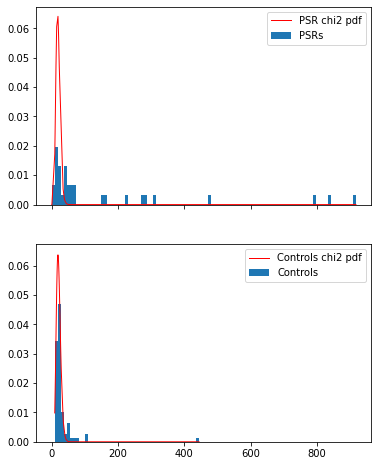

In [43]:
#plotting chi squareds
fig, ax = plt.subplots(2,1, sharex=True, sharey=True, figsize=(6, 8))
x = filtered_final_df.drop([48, 35])['chi_squared'].values
ax[0].plot(x, chi2.pdf(x, mean_psr_dof),'r-', lw=1, label='PSR chi2 pdf')
ax[0].hist(x, bins=np.linspace(0, x.max(), 100), density=True, label='PSRs')
ax[0].legend()

x2 = controls_df.sort_values('chi_squared').drop([5,43,42])['chi_squared'].values
ax[1].plot(x2, chi2.pdf(x2, 21.31111111111111),'r-', lw=1, label='Controls chi2 pdf') #this should be the mean control dof
ax[1].hist(x2, bins=np.linspace(0, x.max(), 100), density=True, label='Controls')
ax[1].legend()

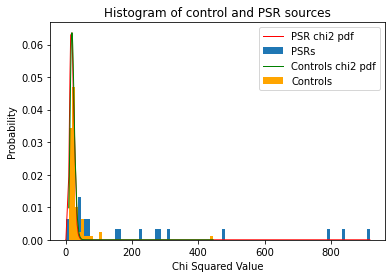

In [47]:
#more comprehensive plots
fig, ax = plt.subplots()
x = filtered_final_df.drop([48,35])['chi_squared'].values
ax.plot(x, chi2.pdf(x, 19.466666666666665),'r-', lw=1, label='PSR chi2 pdf')
ax.hist(x, bins=np.linspace(0, x.max(), 100), density=True, label='PSRs')

x2 = controls_df.sort_values('chi_squared').drop([5,43,42])['chi_squared'].values
ax.plot(x2, chi2.pdf(x2, 21.31111111111111),'g-', lw=1, label='Controls chi2 pdf')
ax.hist(x2, bins=np.linspace(0, x.max(), 100), density=True, color='orange', label='Controls')
ax.set_title('Histogram of control and PSR sources')
ax.set_xlabel('Chi Squared Value')
ax.set_ylabel('Probability')
#ax.set_xscale('log')
ax.legend()
plt.savefig('plots/linear_hist')

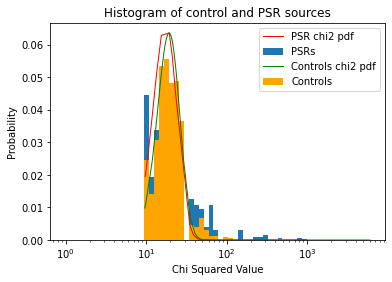

In [51]:
# with log axes
fig, ax = plt.subplots()
x = filtered_final_df.drop([48,35,85,56])['chi_squared'].values
ax.plot(x, chi2.pdf(x, 19.466666666666665),'r-', lw=1, label='PSR chi2 pdf')
ax.hist(x, bins=np.logspace(0,3), density=True, label='PSRs')

x2 = controls_df.sort_values('chi_squared').drop([5])['chi_squared'].values
ax.plot(x2, chi2.pdf(x2, 21.31111111111111),'g-', lw=1, label='Controls chi2 pdf')
ax.hist(x2, bins=np.logspace(0,3), density=True, color='orange', label='Controls')
ax.set_title('Histogram of control and PSR sources')
ax.set_xlabel('Chi Squared Value')
ax.set_ylabel('Probability')
ax.set_xscale('log')
ax.legend()

In [57]:
paper_df = pd.read_csv('paper_df.csv')

In [60]:
stats = paper_df[['DOF', 'control_chi2', 'chi_squared']].drop([0,1,32,33])

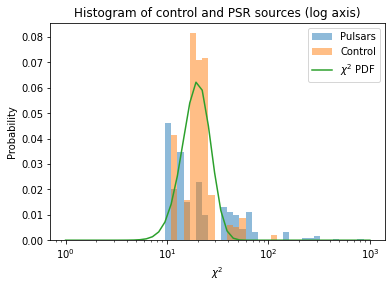

In [64]:
#even better plot
import scipy.stats
from astropy.table import Table

d = stats
meandof = int(round((d["DOF"][d["DOF"] >= 5]).mean()))

chi2 = np.logspace(0, 3)
plt.clf()

plt.hist(
    d["chi_squared"],
    bins=chi2,
    density=True,
    alpha=0.5,
    label="Pulsars",
)
plt.hist(
    d["control_chi2"],
    bins=chi2,
    density=True,
    alpha=0.5,
    label="Control",
)
plt.gca().set_xscale("log")
plt.plot(chi2, scipy.stats.chi2.pdf(chi2, df=meandof), label="$\chi^2$ PDF")
plt.xlabel("$\chi^2$")
plt.ylabel("Probability")
plt.title('Histogram of control and PSR sources (log axis)')
plt.legend()
plt.savefig('plots/log_hist')

In [61]:
#for searching based on name
final_df[final_df['JNAME']=='J1740-3015']

,index,mod_results_index,reduced_chi_squared,separation,modulation,chi_squared,AGE,DM,RAJD_ERR,DECJD,...,GB,S1400,DM_ERR,P0,ASSOC,DECJD_ERR,JNAME,P0_ERR,S1400_ERR,P1
25,75,6,12.86098,1.051999,20.026535,308.663525,20628.7209,151.96,0.000042,-30.262083,...,0.238021,8.9,0.01,0.606887,NaN,0.000056,J1740-3015,3.683114e-11,0.5,4.661238e-13


<Axes: xlabel='P0', ylabel='chi_squared'>

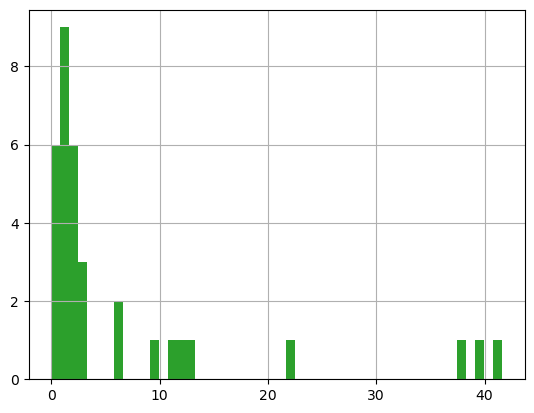

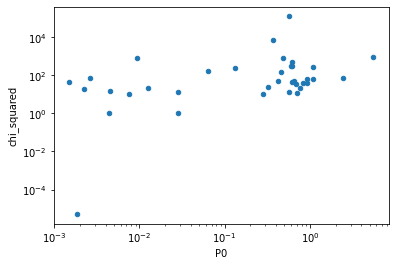

In [39]:
filtered_final_df.plot('P0', 'chi_squared', kind='scatter', loglog=True)

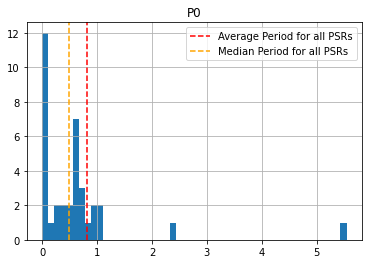

In [40]:
fig, ax = plt.subplots()
filtered_final_df.hist('P0', bins=50, ax=ax)
ax.axvline(pulsars.table['P0'].mean(), label="Average Period for all PSRs", linestyle='dashed', color='r')
ax.axvline(0.4878126283, label="Median Period for all PSRs", linestyle='dashed', color='orange')
ax.legend()

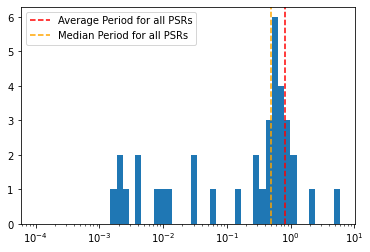

In [41]:
fig, ax = plt.subplots()
plt.hist(filtered_final_df['P0'], bins=np.geomspace(0.0001,6,50))
ax.axvline(pulsars.table['P0'].mean(), label="Average Period for all PSRs", linestyle='dashed', color='r')
ax.axvline(0.4878126283, label="Median Period for all PSRs", linestyle='dashed', color='orange')
ax.set_xscale('log')
ax.legend()

In [76]:
"$\chi^2$"

'$\\chi^2$'

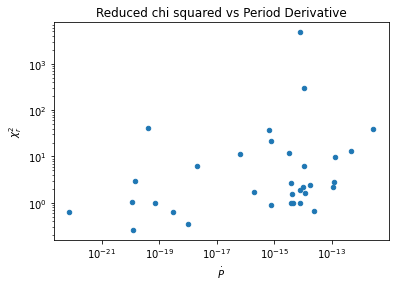

In [82]:
filtered_final_df.plot('P1', 'reduced_chi_squared', kind='scatter', xlabel="$\dot{P}$", ylabel="$\chi_r^2$", title="Reduced chi squared vs Period Derivative", logy=True, logx=True)
plt.savefig('plots/Pdot_redchi')

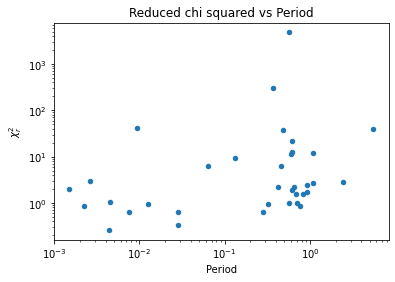

In [86]:
filtered_final_df.plot('P0', 'reduced_chi_squared', kind='scatter', xlabel="Period", ylabel="$\chi_r^2$", title="Reduced chi squared vs Period", logy=True, logx=True)
plt.savefig('plots/P_redchi')

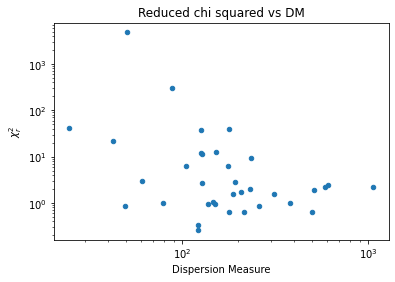

In [87]:
filtered_final_df.plot('DM', 'reduced_chi_squared', kind='scatter', xlabel="Dispersion Measure", ylabel="$\chi_r^2$", title="Reduced chi squared vs DM", logy=True, logx=True)
plt.savefig('plots/DM_redchi')

<Axes: xlabel='P1', ylabel='reduced_chi_squared'>

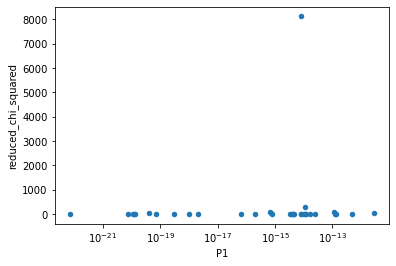

In [48]:
filtered_final_df.plot('P1', 'reduced_chi_squared', kind='scatter', logx=True)

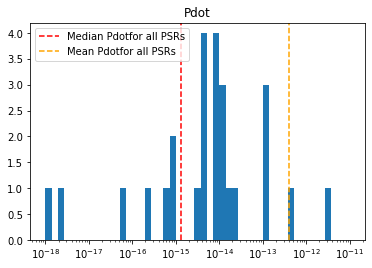

In [42]:
fig, ax = plt.subplots()
#filtered_final_df['P1'].hist(ax=ax, bins=50)
plt.hist(filtered_final_df['P1'], bins=np.geomspace(0.000000000000000001, 0.00000000001, 50))
ax.axvline(1.32e-15, label="Median Pdotfor all PSRs", color='red', linestyle='dashed')
ax.axvline(4.027303098407219e-13, label="Mean Pdotfor all PSRs", color='orange', linestyle='dashed')
ax.set_xscale('log')
ax.set_title("Pdot")
ax.legend()

In [82]:
#lots of very small values for period derivative, less than 10e-13

<Axes: xlabel='AGE', ylabel='chi_squared'>

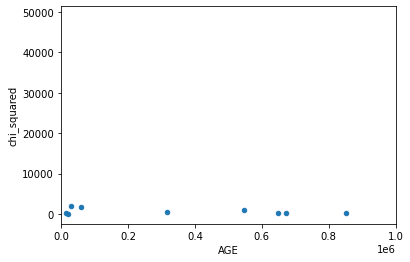

In [83]:
filtered_final_df.plot('AGE', 'chi_squared', kind='scatter', xlim=(0,1000000))

array([[<Axes: title={'center': 'AGE'}>]], dtype=object)

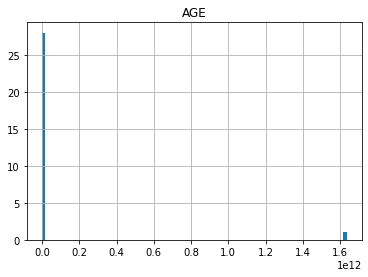

In [182]:
filtered_final_df.hist('AGE', bins=100)

In [183]:
#makes a csv that can be used for the 'find_sources' command line script
#'jake' is just an array filled with the string 'PSR '
import csv

arr1 = filtered_final_df['RAJD'].values

arr2 = filtered_final_df['DECJD'].values

arr3 = filtered_final_df['JNAME'].values

coords_array = np.column_stack((arr1,arr2,np.add(arr3,jake)))

write = csv.writer(open('Coords', 'w'))
write.writerow(['ra','dec','name'])
write.writerows(coords_array.tolist())

Text(0.5, 1.0, 'PSR J1705-3423\nchi^2 = 42.6\nreduced chi^2 = 2.67, DOF = 16')

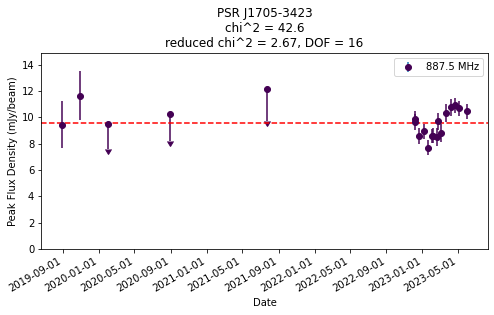

In [97]:
#making lightcurve with dashed line for mean flux
modified_results[0].plot_lightcurve()
plt.axhline(modified_results[0].measurements['flux_peak'].mean(), color='red', linestyle='dashed', label='Mean flux')
ra = modified_results[0].measurements['skycoord'][0].ra.deg
dec = modified_results[0].measurements['skycoord'][0].dec.deg
index = final_df[(final_df['RAJD']==ra)&(final_df['DECJD']==dec)].index[0]
name = final_df['JNAME'][index]
chi = final_df['chi_squared'][index]
reduced_chi = final_df['reduced_chi_squared'][index]
plt.title("PSR " + name + "\nchi^2 = {:.1f}".format(chi) +"\nreduced chi^2 = {:.2f}".format(reduced_chi) + ", DOF = {:.0f}".format(chi_squared(modified_results[0].measurements)[1] -1 ))
#plt.savefig('lightcurves/' + name)
#plt.legend()

In [110]:
for i in np.arange(modified_results.size):
    modified_results[i].plot_lightcurve()
    plt.axhline(modified_results[i].measurements['flux_peak'].mean(), color='red', linestyle='dashed', label='Mean flux')
    ra = modified_results[i].measurements['skycoord'][0].ra.deg
    dec = modified_results[i].measurements['skycoord'][0].dec.deg
    index = final_df[(final_df['RAJD']==ra)&(final_df['DECJD']==dec)].index[0]
    name = final_df['JNAME'][index]
    chi = final_df['chi_squared'][index]
    reduced_chi = final_df['reduced_chi_squared'][index]
    plt.title("PSR " + name + "\nchi^2 = {:.1f}".format(chi) +"\nreduced chi^2 = {:.2f}".format(reduced_chi) + ", DOF = {:.0f}".format(chi_squared(modified_results[0].measurements)[1] -1 ))
    plt.savefig('lightcurves_new/' + name, bbox_inches='tight', pad_inches=2)
    plt.close()

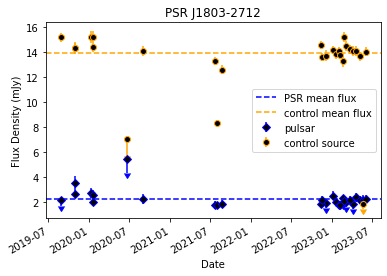

In [197]:
#basically makes a lightcurve, largely copied from 'plot_lightcurves' source code
sigma_thresh=5
figsize = (8, 4)
min_points = 2
min_detections = 0
mjd= False
# TODO: Is this a pd.Timestamp or a datetime?
start_date = None
grid= False
yaxis_start = "0"
peak_flux= True
save = False
outfile = None
use_forced_for_limits = False
use_forced_for_all = False
hide_legend = False
plot_dpi = 150

fig, ax = plt.subplots()

measurements = modified_results[38].measurements

upper_lim_mask = measurements.detection == False
upper_lims = measurements[upper_lim_mask]

plot_dates = measurements['dateobs']

value_col = err_value_col = 'rms_image'
uplims = True
flux_col = "flux_peak"

marker = "D"
markerfacecolor = 'k'

if upper_lim_mask.any():
        upperlim_points = ax.errorbar(
            plot_dates[upper_lim_mask],
            sigma_thresh *
            upper_lims[value_col],
            yerr=upper_lims[err_value_col],
            uplims=uplims,
            lolims=False,
            marker=marker,
            c='blue',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            #label=label
        )
        
detections = measurements[~upper_lim_mask]
marker = 'D'
markerfacecolor = 'k'
        
if (~upper_lim_mask).any():
        detection_points = ax.errorbar(
            plot_dates[~upper_lim_mask],
            detections[flux_col],
            yerr=detections[err_value_col],
            marker=marker,
            c='blue',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            label='pulsar'
        )
        
measurements = control_source.measurements

upper_lim_mask = measurements.detection == False
upper_lims = measurements[upper_lim_mask]

plot_dates = measurements['dateobs']

value_col = err_value_col = 'rms_image'
uplims = True
flux_col = "flux_peak"

marker = "o"
markerfacecolor = 'k'

if upper_lim_mask.any():
        upperlim_points = ax.errorbar(
            plot_dates[upper_lim_mask],
            sigma_thresh *
            upper_lims[value_col],
            yerr=upper_lims[err_value_col],
            uplims=uplims,
            lolims=False,
            marker=marker,
            c='orange',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            #label=label
        )
        
detections = measurements[~upper_lim_mask]
marker = 'o'
markerfacecolor = 'k'
        
if (~upper_lim_mask).any():
        detection_points = ax.errorbar(
            plot_dates[~upper_lim_mask],
            detections[flux_col],
            yerr=detections[err_value_col],
            marker=marker,
            c='orange',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            label='control source'
        )
        
ax.axhline(modified_results[38].measurements['flux_peak'].mean(), linestyle='dashed', label='PSR mean flux', color='blue')
ax.axhline(control_source.measurements['flux_peak'].mean(), linestyle='dashed', label='control mean flux', color='orange')


fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Flux Density (mJy)')
name = final_df[final_df['mod_results_index'] == 38]['JNAME'].values[0]
ax.set_title("PSR " + name)
ax.legend()

plt.savefig('complete_lightcurves/' + name, bbox_inches='tight', pad_inches=2)  # saving to a folder
#date_form = mdates.DateFormatter("%Y-%m-%d")
#ax.xaxis.set_major_formatter(date_form)
#ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=15))

In [111]:
#making lightcurves for each pulsar and saving them to a folder
for i in np.arange(modified_results.size):
    step = contorls_df.shape[0] / modified_results.size #this could cause problems, and should always evaluate to an integer
    query_coord = SkyCoord(str(controls_df.iloc[i*step]['ra_deg_cont']) + " " + str(controls_df.iloc[i*step]['dec_deg_cont']), unit='deg')
    query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False)
    query.find_sources()
    control_source = query.results[0]

    #basically makes a lightcurve, largely copied from 'plot_lightcurves' source code
    sigma_thresh=5
    figsize = (8, 4)
    min_points = 2
    min_detections = 0
    mjd= False
    # TODO: Is this a pd.Timestamp or a datetime?
    start_date = None
    grid= False
    yaxis_start = "0"
    peak_flux= True
    save = False
    outfile = None
    use_forced_for_limits = False
    use_forced_for_all = False
    hide_legend = False
    plot_dpi = 150
    
    fig, ax = plt.subplots()
    
    measurements = modified_results[i].measurements
    
    upper_lim_mask = measurements.detection == False
    upper_lims = measurements[upper_lim_mask]
    
    plot_dates = measurements['dateobs']
    
    value_col = err_value_col = 'rms_image'
    uplims = True
    flux_col = "flux_peak"
    
    marker = "D"
    markerfacecolor = 'k'
    
    if upper_lim_mask.any():
            upperlim_points = ax.errorbar(
                plot_dates[upper_lim_mask],
                sigma_thresh *
                upper_lims[value_col],
                yerr=upper_lims[err_value_col],
                uplims=uplims,
                lolims=False,
                marker=marker,
                c='blue',
                linestyle="none",
                markerfacecolor=markerfacecolor,
                #label=label
            )
        
    detections = measurements[~upper_lim_mask]
    marker = 'D'
    markerfacecolor = 'k'
            
    if (~upper_lim_mask).any():
            detection_points = ax.errorbar(
                plot_dates[~upper_lim_mask],
                detections[flux_col],
                yerr=detections[err_value_col],
                marker=marker,
                c='blue',
                linestyle="none",
                markerfacecolor=markerfacecolor,
                label='pulsar'
            )
        
    measurements = control_source.measurements
    
    upper_lim_mask = measurements.detection == False
    upper_lims = measurements[upper_lim_mask]
    
    plot_dates = measurements['dateobs']
    
    value_col = err_value_col = 'rms_image'
    uplims = True
    flux_col = "flux_peak"
    
    marker = "o"
    markerfacecolor = 'k'
    
    if upper_lim_mask.any():
            upperlim_points = ax.errorbar(
                plot_dates[upper_lim_mask],
                sigma_thresh *
                upper_lims[value_col],
                yerr=upper_lims[err_value_col],
                uplims=uplims,
                lolims=False,
                marker=marker,
                c='orange',
                linestyle="none",
                markerfacecolor=markerfacecolor,
                #label=label
            )
        
    detections = measurements[~upper_lim_mask]
    marker = 'o'
    markerfacecolor = 'k'
        
    if (~upper_lim_mask).any():
            detection_points = ax.errorbar(
                plot_dates[~upper_lim_mask],
                detections[flux_col],
                yerr=detections[err_value_col],
                marker=marker,
                c='orange',
                linestyle="none",
                markerfacecolor=markerfacecolor,
                label='control source'
            )
        
    ax.axhline(modified_results[i].measurements['flux_peak'].mean(), linestyle='dashed', label='PSR mean flux', color='blue')
    ax.axhline(control_source.measurements['flux_peak'].mean(), linestyle='dashed', label='control mean flux', color='orange')
    
    
    fig.autofmt_xdate()
    ax.set_xlabel('Date')
    ax.set_ylabel('Flux Density (mJy)')
    name = final_df[final_df['mod_results_index'] == i]['JNAME'].values[0]
    ax.set_title("PSR " + name)
    ax.legend()
    
    plt.savefig('complete_lightcurves/' + name, bbox_inches='tight', pad_inches=2)
    plt.close()

Removing source_170544.5-341722.0: Epoch 5x due to missing files
Removing source_170544.5-341722.0: Epoch 6x due to missing files
Removing source_170544.5-341722.0: Epoch 8 due to missing files
Removing source_170825.5-342634.2: Epoch 5x due to missing files
Removing source_170825.5-342634.2: Epoch 6x due to missing files
Removing source_170825.5-342634.2: Epoch 8 due to missing files
Removing source_172101.6-352010.5: Epoch 5x due to missing files
Removing source_172101.6-352010.5: Epoch 6x due to missing files
Removing source_172101.6-352010.5: Epoch 8 due to missing files
Removing source_172101.6-352010.5: Epoch 20 due to missing files
Removing source_172101.6-352010.5: Epoch 21 due to missing files
Removing source_172308.0-283840.2: Epoch 5x due to missing files
Removing source_172308.0-283840.2: Epoch 6x due to missing files
Removing source_172308.0-283840.2: Epoch 8 due to missing files
Removing source_172308.0-283840.2: Epoch 20 due to missing files
Removing source_172308.0-2838